# Simple Data Set Analysis

## Imports

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set global style for plots
plt.style.use('seaborn-v0_8-darkgrid')

## Load the dataset

In [6]:
# Load the dataset
df = pd.read_csv("simple_data.csv")
df

,player_id,level,attempt,time_to_complete,deaths,shots_fired,shots_hit,heals_used,distance_travelled
0,P1,1,1,108,0,44,35,0,140.0
1,P7,1,1,82,2,64,24,1,170.0
2,P3,2,1,129,1,52,42,1,166.0
3,P9,1,1,76,1,60,23,0,165.0
4,P5,3,1,146,1,55,45,1,181.0
5,P2,1,1,74,1,58,22,0,160.0
6,P8,2,1,88,3,72,27,2,198.0
7,P4,4,1,151,2,63,51,2,195.0
8,P10,2,1,85,2,68,26,1,193.0
9,P6,2,1,124,0,47,38,0,158.0


## Create 2-3 summary metrics per player

In [ ]:
# Create 2-3 summary metrics per player (mean deaths, mean time, accuracy)
means = (
	df.assign(accuracy=df["shots_hit"] / df["shots_fired"])
	  .groupby("player_id")[["deaths", "time_to_complete", "accuracy"]]
	  .mean()
	  .round(2)
)
means

,deaths,time_to_complete,accuracy
player_id,,,
P1,1.00,136.83,0.81
P10,3.17,92.83,0.38
P2,2.67,88.67,0.38
P3,1.17,143.17,0.82
P4,1.17,142.33,0.82
P5,1.00,145.50,0.82
P6,0.80,135.00,0.82
P7,3.60,96.00,0.38
P8,3.33,92.33,0.37


## Visualize distributions per player

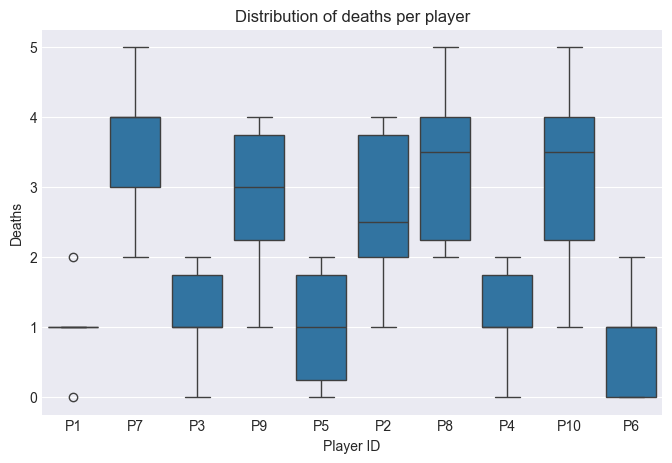

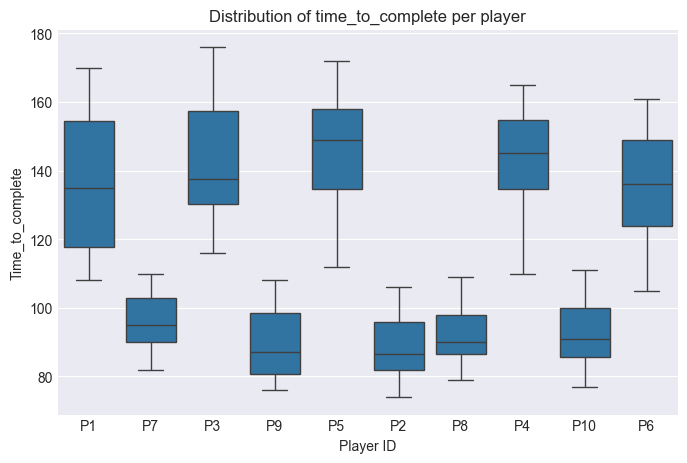

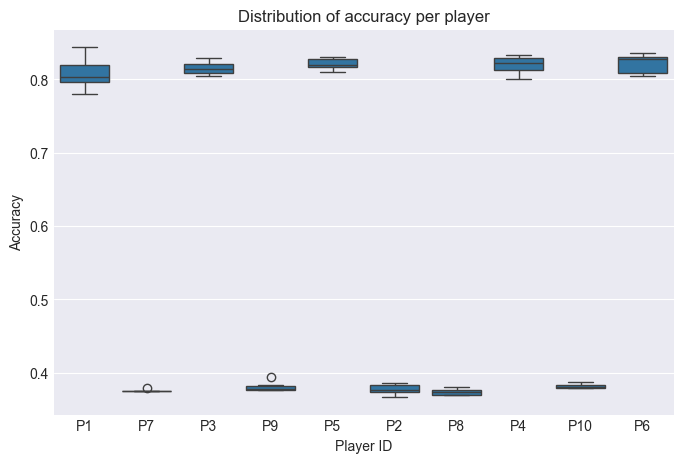

In [ ]:
metrics = ["deaths", "time_to_complete", "accuracy"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="player_id", y=metric, data=df.assign(accuracy=df["shots_hit"] / df["shots_fired"]))
    plt.title(f"Distribution of {metric} per player")
    plt.xlabel("Player ID")
    plt.ylabel(metric.capitalize())
    plt.show()

## Interpretations

### Are there behavior differences that you observe?
The players form two groups. P1, P3, P4, P5, and P6 have around 0.82 accuracy, roughly 1 death on average, and completion times between 135 and 146 seconds. P2, P7, P8, P9, and P10 sit at 0.37-0.38 accuracy, die 2.7 to 3.6 times on average, and finish levels in 89 to 96 seconds. All three metrics move together: no player is fast and accurate, or slow and inaccurate. This suggests that these aren't independent differences but rather two coherent ways of playing the game.

### What experience hypotheses could explain them?
One explanation is that the accurate group has more experience with this type of game. They've likely developed an understanding of when to engage and when to hold fire, which explains both the high hit rate and the low deaths. Their longer completion times probably reflect deliberate navigation rather than difficulty. The other group may still be learning the game's rhythm, firing reactively at threats as they appear, which would explain why they hit so few shots and die so often. Their faster times could simply be a consequence of dying earlier in each attempt rather than actually being more efficient. That said, this could also reflect a difference in intent rather than skill. Some players genuinely prefer to play fast and loose, accepting deaths as a trade-off for a more action-heavy experience, while others find more value in a controlled, precise approach.